# Stadium Intro Analysis

Parameterized notebook for comparing individual stadium weather and play statistics against league averages.

**To switch teams**: Change `TEAM` in the cell below and re-run all cells. Season range auto-loads from `team_parameters.csv` but can be overridden.

In [1]:
# ============================================================
# PARAMETERS — change these to switch teams
# ============================================================
TEAM = 'BOS'  # <- change this (see team_parameters.csv for all codes)

# Season range auto-loaded from team_parameters.csv.
# Uncomment below to override:
# SEASON_START = 2021
# SEASON_END = 2025

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# --- Auto-configuration from team_parameters.csv ---
params_df = pd.read_csv('team_parameters.csv')
team_row = params_df[params_df['team_code'] == TEAM]
if len(team_row) == 0:
    raise ValueError(f"Team '{TEAM}' not found in team_parameters.csv. Valid codes: {sorted(params_df['team_code'].tolist())}")
team_row = team_row.iloc[0]

TEAM_NAME = team_row['team_name']
STADIUM_NAME = team_row['stadium_name']
DATASET_FILE = team_row['dataset_file']

# Use auto-loaded season range unless user overrode above
if 'SEASON_START' not in dir():
    SEASON_START = int(team_row['data_start_year'])
if 'SEASON_END' not in dir():
    SEASON_END = int(team_row['data_end_year'])

DATASETS_DIR = os.path.join('..', 'Stadium Datasets', 'Final Datasets')

# --- Graphics output directory ---
GRAPHICS_DIR = os.path.join('intro_graphics', TEAM)
os.makedirs(GRAPHICS_DIR, exist_ok=True)

print(f"{'='*60}")
print(f"  {STADIUM_NAME} ({TEAM_NAME})")
print(f"  Team code: {TEAM}")
print(f"  Seasons: {SEASON_START}-{SEASON_END}")
print(f"  Dataset: {DATASET_FILE}")
print(f"  Graphics output: {os.path.abspath(GRAPHICS_DIR)}")
print(f"{'='*60}")

/Users/avabrown/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/avabrown/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


  Fenway Park (Red Sox)
  Team code: BOS
  Seasons: 2016-2025
  Dataset: fenway_data_2016.csv
  Graphics output: /Users/avabrown/Desktop/DATASCI 192A/Stadium Analysis/Intro Analysis/intro_graphics/BOS


In [3]:
# --- Load team data ---
team_data = pd.read_csv(os.path.join(DATASETS_DIR, DATASET_FILE))
team_data['game_date'] = pd.to_datetime(team_data['game_date'])
team_data = team_data[
    (team_data['season'] >= SEASON_START) &
    (team_data['season'] <= SEASON_END)
].copy()

print(f"Team data: {len(team_data)} games ({SEASON_START}-{SEASON_END})")
print(f"Seasons: {sorted(team_data['season'].unique())}")

# --- Load league weather data ---
league_data = pd.read_csv(os.path.join(DATASETS_DIR, 'league_weather_2021_2025.csv'))
league_data['game_date'] = pd.to_datetime(league_data['game_date'])

print(f"League data: {len(league_data)} games (2021-2025, 30 stadiums)")
print(f"\nTeam weather summary:")
print(team_data[['temp_f', 'wspd_mph', 'rhum', 'pres']].describe().round(1))

Team data: 758 games (2016-2025)
Seasons: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
League data: 12058 games (2021-2025, 30 stadiums)

Team weather summary:
       temp_f  wspd_mph   rhum    pres
count   758.0     758.0  758.0   758.0
mean     65.9       7.9   69.7  1013.9
std      11.6       3.5   18.5     6.3
min      32.4       0.5   20.3   988.5
25%      58.3       5.4   57.0  1009.8
50%      67.3       7.4   72.3  1013.7
75%      73.9       9.9   84.7  1017.9
max     100.8      21.4   99.7  1035.2


## Weather Distribution: Stadium vs League Average

Comparing the distribution of weather conditions at this stadium against the league-wide distribution (2021-2025).

In [4]:
# Filter team data to the league comparison window (2021-2025)
team_league_window = team_data[
    (team_data['season'] >= 2021) & (team_data['season'] <= 2025)
].copy()

print(f"Team games in league comparison window (2021-2025): {len(team_league_window)}")
print(f"League games: {len(league_data)}")

Team games in league comparison window (2021-2025): 405
League games: 12058


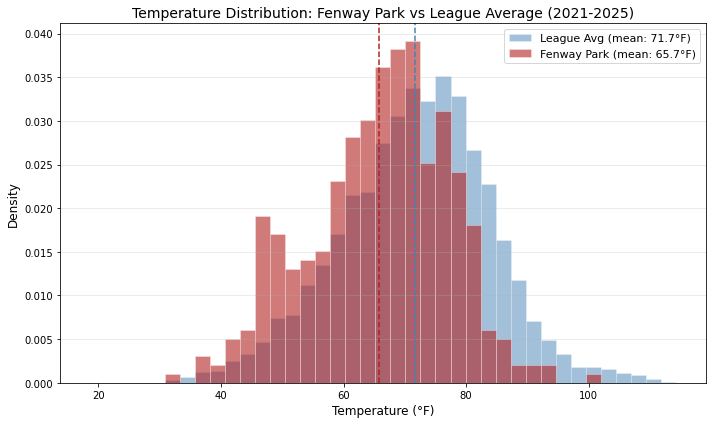

In [5]:
# --- Temperature Distribution ---
fig, ax = plt.subplots(figsize=(10, 6))

team_vals = team_league_window['temp_f'].dropna()
league_vals = league_data['temp_f'].dropna()

bins = np.linspace(
    min(team_vals.min(), league_vals.min()) - 2,
    max(team_vals.max(), league_vals.max()) + 2,
    40
)

ax.hist(league_vals, bins=bins, density=True, alpha=0.5, color='steelblue',
        edgecolor='white', linewidth=0.5, label=f'League Avg (mean: {league_vals.mean():.1f}\u00b0F)')
ax.hist(team_vals, bins=bins, density=True, alpha=0.6, color='firebrick',
        edgecolor='white', linewidth=0.5, label=f'{STADIUM_NAME} (mean: {team_vals.mean():.1f}\u00b0F)')

ax.axvline(league_vals.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(team_vals.mean(), color='firebrick', linestyle='--', linewidth=1.5)

ax.set_xlabel('Temperature (\u00b0F)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Temperature Distribution: {STADIUM_NAME} vs League Average (2021-2025)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(GRAPHICS_DIR, 'temperature_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

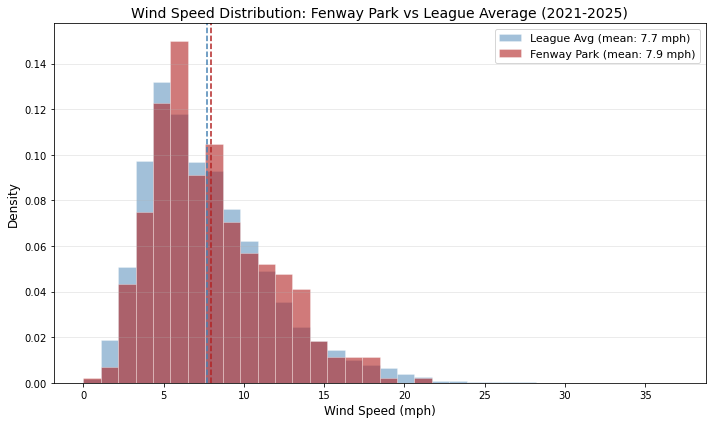

In [6]:
# --- Wind Speed Distribution ---
fig, ax = plt.subplots(figsize=(10, 6))

team_vals = team_league_window['wspd_mph'].dropna()
league_vals = league_data['wspd_mph'].dropna()

bins = np.linspace(0, max(team_vals.max(), league_vals.max()) + 1, 35)

ax.hist(league_vals, bins=bins, density=True, alpha=0.5, color='steelblue',
        edgecolor='white', linewidth=0.5, label=f'League Avg (mean: {league_vals.mean():.1f} mph)')
ax.hist(team_vals, bins=bins, density=True, alpha=0.6, color='firebrick',
        edgecolor='white', linewidth=0.5, label=f'{STADIUM_NAME} (mean: {team_vals.mean():.1f} mph)')

ax.axvline(league_vals.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(team_vals.mean(), color='firebrick', linestyle='--', linewidth=1.5)

ax.set_xlabel('Wind Speed (mph)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Wind Speed Distribution: {STADIUM_NAME} vs League Average (2021-2025)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(GRAPHICS_DIR, 'wind_speed_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

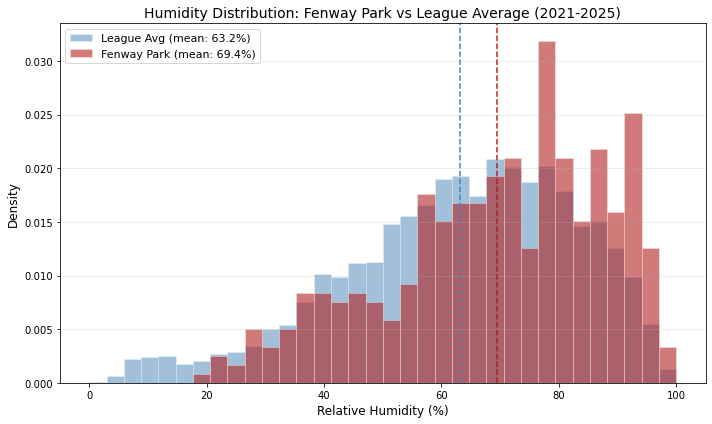

In [7]:
# --- Humidity Distribution ---
fig, ax = plt.subplots(figsize=(10, 6))

team_vals = team_league_window['rhum'].dropna()
league_vals = league_data['rhum'].dropna()

bins = np.linspace(0, 100, 35)

ax.hist(league_vals, bins=bins, density=True, alpha=0.5, color='steelblue',
        edgecolor='white', linewidth=0.5, label=f'League Avg (mean: {league_vals.mean():.1f}%)')
ax.hist(team_vals, bins=bins, density=True, alpha=0.6, color='firebrick',
        edgecolor='white', linewidth=0.5, label=f'{STADIUM_NAME} (mean: {team_vals.mean():.1f}%)')

ax.axvline(league_vals.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(team_vals.mean(), color='firebrick', linestyle='--', linewidth=1.5)

ax.set_xlabel('Relative Humidity (%)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Humidity Distribution: {STADIUM_NAME} vs League Average (2021-2025)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(GRAPHICS_DIR, 'humidity_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

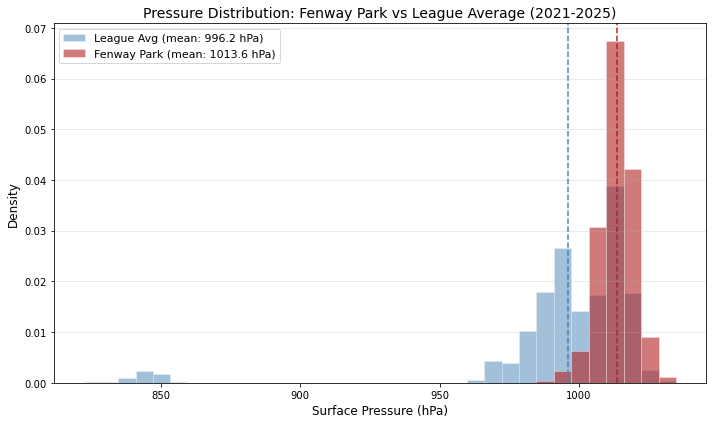

In [8]:
# --- Pressure Distribution ---
fig, ax = plt.subplots(figsize=(10, 6))

team_vals = team_league_window['pres'].dropna()
league_vals = league_data['pres'].dropna()

bins = np.linspace(
    min(team_vals.min(), league_vals.min()) - 2,
    max(team_vals.max(), league_vals.max()) + 2,
    35
)

ax.hist(league_vals, bins=bins, density=True, alpha=0.5, color='steelblue',
        edgecolor='white', linewidth=0.5, label=f'League Avg (mean: {league_vals.mean():.1f} hPa)')
ax.hist(team_vals, bins=bins, density=True, alpha=0.6, color='firebrick',
        edgecolor='white', linewidth=0.5, label=f'{STADIUM_NAME} (mean: {team_vals.mean():.1f} hPa)')

ax.axvline(league_vals.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(team_vals.mean(), color='firebrick', linestyle='--', linewidth=1.5)

ax.set_xlabel('Surface Pressure (hPa)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Pressure Distribution: {STADIUM_NAME} vs League Average (2021-2025)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(GRAPHICS_DIR, 'pressure_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## OLS Regression: Weather Effects on Game Outcomes

Ordinary least squares regression examining the relationship between weather conditions
and game outcomes (total runs, strikeouts, HR:H ratio). Each dependent variable is
regressed on available weather statistics for three subsets: all games, day games only
(start before 5:00 PM local), and night games only (start at 5:00 PM or later).

**Independent variables**: Temperature (F), Relative Humidity, Surface Pressure,
Precipitation, Wind Speed (mph), Wind to CF, Wind to LCF, Wind to RCF.

In [9]:
import statsmodels.api as sm

# --- Regression Configuration ---
DEPENDENT_VARS = {
    'total_runs': 'Total Runs',
    'strikeouts': 'Strikeouts',
    'hr_h_ratio': 'HR:H Ratio',
}

INDEPENDENT_VARS = [
    'temp_f', 'rhum', 'pres', 'prcp', 'wspd_mph',
    'wind_cf', 'wind_lcf', 'wind_rcf',
]

IV_DISPLAY_NAMES = {
    'temp_f': 'Temp (F)',
    'rhum': 'Humidity (%)',
    'pres': 'Pressure (hPa)',
    'prcp': 'Precip (mm)',
    'wspd_mph': 'Wind Speed (mph)',
    'wind_cf': 'Wind to CF',
    'wind_lcf': 'Wind to LCF',
    'wind_rcf': 'Wind to RCF',
    'const': 'Intercept',
}

SUBSETS = {
    'all': 'All Games',
    'day': 'Day Games (before 5 PM)',
    'night': 'Night Games (5 PM+)',
}


def run_ols(df, dep_var, indep_vars):
    """Run OLS regression, dropping rows with NaN in any regression variable."""
    cols_needed = [dep_var] + indep_vars
    reg_df = df[cols_needed].dropna()
    n_dropped = len(df) - len(reg_df)

    X = sm.add_constant(reg_df[indep_vars])
    y = reg_df[dep_var]

    model = sm.OLS(y, X).fit()
    return model, n_dropped


def results_to_dataframe(model):
    """Extract a clean summary DataFrame from an OLS result."""
    summary_df = pd.DataFrame({
        'Variable': [IV_DISPLAY_NAMES.get(v, v) for v in model.params.index],
        'Coefficient': model.params.values,
        'Std Error': model.bse.values,
        't-stat': model.tvalues.values,
        'P-value': model.pvalues.values,
    })

    def sig_stars(p):
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        if p < 0.10:  return '.'
        return ''

    summary_df['Sig'] = summary_df['P-value'].apply(sig_stars)

    summary_df['Coefficient'] = summary_df['Coefficient'].round(4)
    summary_df['Std Error'] = summary_df['Std Error'].round(4)
    summary_df['t-stat'] = summary_df['t-stat'].round(3)
    summary_df['P-value'] = summary_df['P-value'].round(4)

    return summary_df


def render_regression_table(results_df, model, dep_label, subset_label,
                            n_obs, n_dropped, filepath):
    """Render regression results as a matplotlib table and save to filepath."""
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.axis('off')

    title = (f'OLS Regression: {dep_label}\n'
             f'{STADIUM_NAME} \u2014 {subset_label} ({SEASON_START}-{SEASON_END})')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20, loc='left')

    col_labels = results_df.columns.tolist()
    cell_text = results_df.values.tolist()

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='center',
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.4)

    # Style header row
    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Alternate row shading
    for i in range(1, len(cell_text) + 1):
        for j in range(len(col_labels)):
            if i % 2 == 0:
                table[i, j].set_facecolor('#f0f0f0')

    # Model summary footer
    summary_text = (
        f'n = {n_obs}    '
        f'R\u00b2 = {model.rsquared:.4f}    '
        f'Adj R\u00b2 = {model.rsquared_adj:.4f}    '
        f'F = {model.fvalue:.2f} (p = {model.f_pvalue:.4f})'
    )
    if n_dropped > 0:
        summary_text += f'    [{n_dropped} obs dropped due to missing data]'

    fig.text(0.05, 0.02, summary_text, fontsize=9, fontstyle='italic', color='#555555')
    fig.text(0.95, 0.02, 'Sig: *** p<0.001  ** p<0.01  * p<0.05  . p<0.10',
             fontsize=8, ha='right', color='#888888')

    plt.tight_layout()
    fig.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

In [10]:
# --- Tag day vs night games ---
team_data['is_day'] = team_data['start_hour'] < 17

n_day = team_data['is_day'].sum()
n_night = (~team_data['is_day']).sum()
print(f"Day games (start before 5 PM):  {n_day}")
print(f"Night games (start 5 PM+):      {n_night}")
print(f"Total:                           {len(team_data)}")

# --- Define subsets ---
subsets = {
    'all': team_data,
    'day': team_data[team_data['is_day']],
    'night': team_data[~team_data['is_day']],
}

# --- Run all 9 regressions ---
all_results = {}

for dep_var, dep_label in DEPENDENT_VARS.items():
    print(f"\n{'='*60}")
    print(f"  Dependent Variable: {dep_label} ({dep_var})")
    print(f"{'='*60}")

    for subset_key, subset_label in SUBSETS.items():
        subset_df = subsets[subset_key]
        model, n_dropped = run_ols(subset_df, dep_var, INDEPENDENT_VARS)

        results_df = results_to_dataframe(model)
        n_obs = int(model.nobs)

        all_results[(dep_var, subset_key)] = {
            'model': model,
            'results_df': results_df,
            'n_obs': n_obs,
            'n_dropped': n_dropped,
            'dep_label': dep_label,
            'subset_label': subset_label,
        }

        print(f"\n  {subset_label}: n={n_obs}, R²={model.rsquared:.4f}, "
              f"Adj R²={model.rsquared_adj:.4f}, F={model.fvalue:.2f}")

Day games (start before 5 PM):  255
Night games (start 5 PM+):      503
Total:                           758

  Dependent Variable: Total Runs (total_runs)

  All Games: n=758, R²=0.0500, Adj R²=0.0399, F=4.93

  Day Games (before 5 PM): n=255, R²=0.0937, Adj R²=0.0643, F=3.18

  Night Games (5 PM+): n=503, R²=0.0449, Adj R²=0.0294, F=2.90

  Dependent Variable: Strikeouts (strikeouts)

  All Games: n=758, R²=0.0039, Adj R²=-0.0067, F=0.37

  Day Games (before 5 PM): n=255, R²=0.0188, Adj R²=-0.0131, F=0.59

  Night Games (5 PM+): n=503, R²=0.0136, Adj R²=-0.0023, F=0.85

  Dependent Variable: HR:H Ratio (hr_h_ratio)

  All Games: n=758, R²=0.0385, Adj R²=0.0283, F=3.75

  Day Games (before 5 PM): n=255, R²=0.0750, Adj R²=0.0449, F=2.49

  Night Games (5 PM+): n=503, R²=0.0396, Adj R²=0.0240, F=2.54


Saving regression tables to: /Users/avabrown/Desktop/DATASCI 192A/Stadium Analysis/Intro Analysis/intro_graphics/BOS



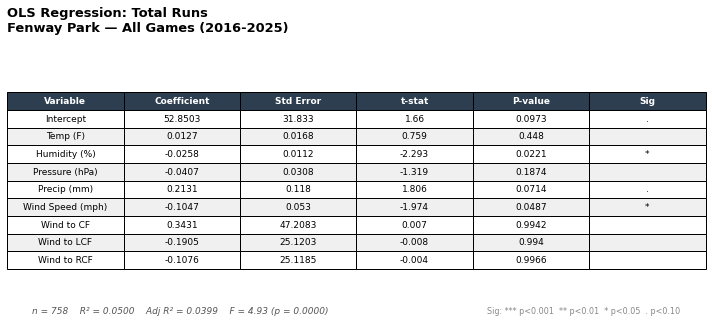

  Saved: ols_total_runs_all.png


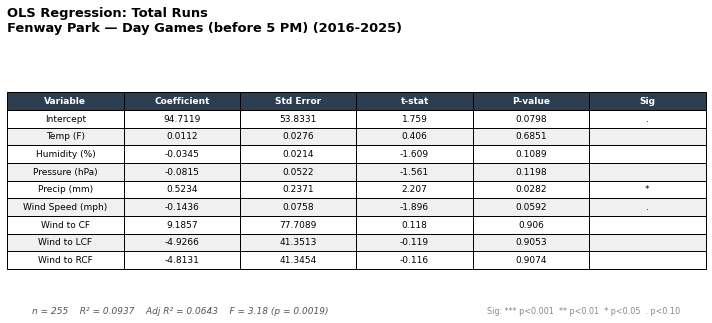

  Saved: ols_total_runs_day.png


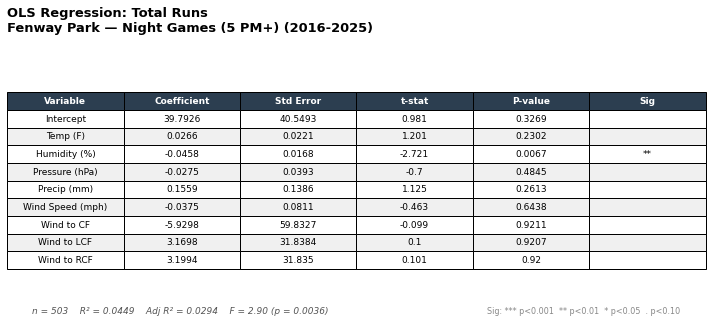

  Saved: ols_total_runs_night.png


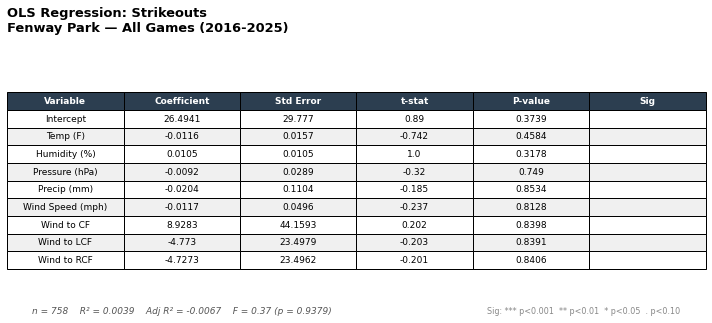

  Saved: ols_strikeouts_all.png


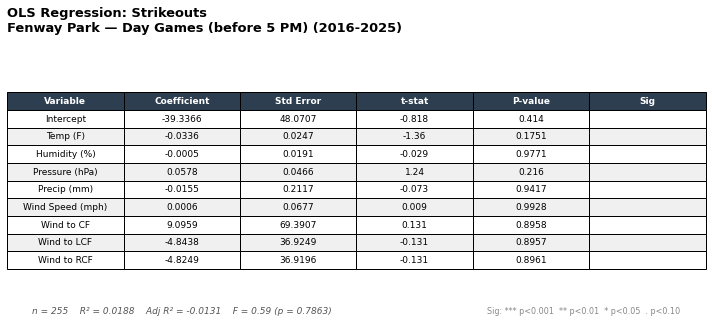

  Saved: ols_strikeouts_day.png


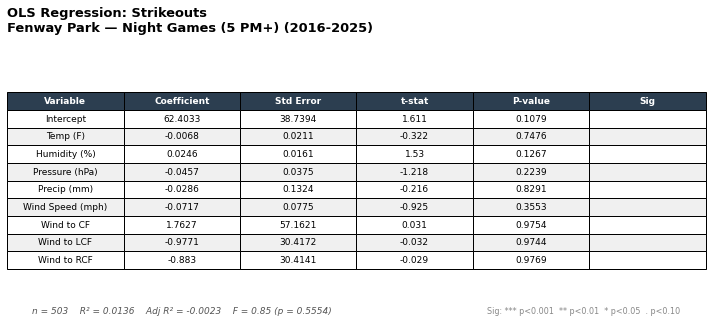

  Saved: ols_strikeouts_night.png


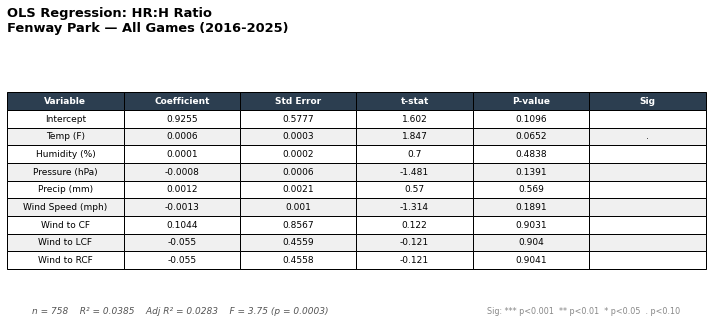

  Saved: ols_hr_h_ratio_all.png


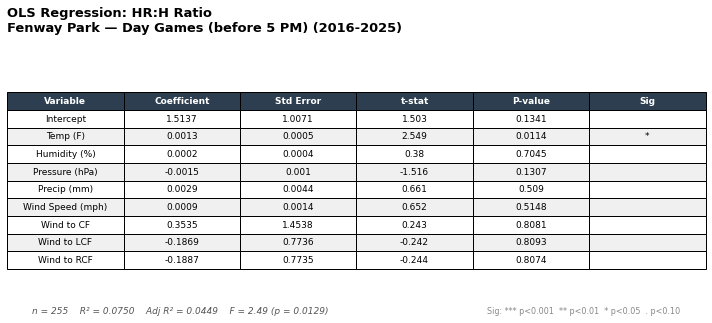

  Saved: ols_hr_h_ratio_day.png


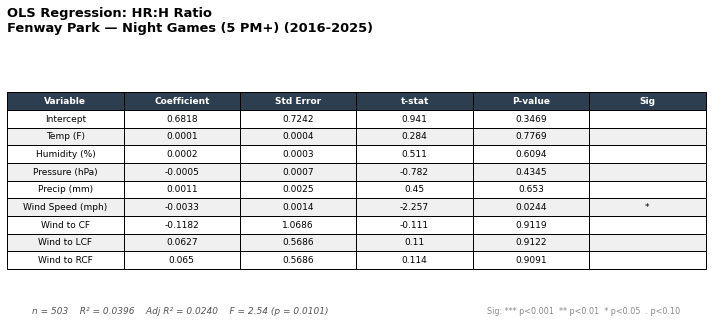

  Saved: ols_hr_h_ratio_night.png

All 9 regression tables saved.


In [11]:
# --- Render and save all regression tables ---
print(f"Saving regression tables to: {os.path.abspath(GRAPHICS_DIR)}\n")

for dep_var, dep_label in DEPENDENT_VARS.items():
    for subset_key, subset_label in SUBSETS.items():
        r = all_results[(dep_var, subset_key)]

        filename = f'ols_{dep_var}_{subset_key}.png'
        filepath = os.path.join(GRAPHICS_DIR, filename)

        render_regression_table(
            results_df=r['results_df'],
            model=r['model'],
            dep_label=r['dep_label'],
            subset_label=r['subset_label'],
            n_obs=r['n_obs'],
            n_dropped=r['n_dropped'],
            filepath=filepath,
        )

        print(f"  Saved: {filename}")

print(f"\nAll {len(all_results)} regression tables saved.")

## Weather Impact Heatmaps

Mean baseball statistics bucketed by weather conditions. **Raw** heatmaps show the
mean value of each stat within each weather quintile. **Diff** heatmaps show the
difference from the overall mean (positive = above average, negative = below average).

Colors are normalized row-by-row since the five statistics have very different scales.
Game counts per bucket are shown in the column headers.

In [12]:
from matplotlib.colors import Normalize, TwoSlopeNorm

# --- Heatmap Configuration ---
WEATHER_VARS = {
    'temp_f':   {'label': 'Temperature',  'unit': '\u00b0F',  'n_bins': 5, 'fmt': '.0f'},
    'wspd_mph': {'label': 'Wind Speed',   'unit': ' mph',     'n_bins': 5, 'fmt': '.0f'},
    'rhum':     {'label': 'Humidity',      'unit': '%',        'n_bins': 5, 'fmt': '.0f'},
    'pres':     {'label': 'Pressure',      'unit': ' hPa',     'n_bins': 5, 'fmt': '.0f'},
}

BASEBALL_STATS = {
    'total_runs':    {'label': 'Total Runs',  'fmt': '.1f'},
    'home_runs_hit': {'label': 'Home Runs',   'fmt': '.2f'},
    'strikeouts':    {'label': 'Strikeouts',  'fmt': '.1f'},
    'walks':         {'label': 'Walks',       'fmt': '.1f'},
    'hr_h_ratio':    {'label': 'HR:H Ratio',  'fmt': '.3f'},
}


def bucket_weather_var(df, col, config):
    """Bucket a numeric weather column into quantile bins.
    Returns (bucket_labels Series, bucket_order list, counts dict)."""
    series = df[col].dropna()
    buckets = pd.qcut(series, q=config['n_bins'], duplicates='drop')

    # Build readable labels and an ordered list
    label_map = {}
    for interval in buckets.cat.categories:
        left = format(interval.left, config['fmt'])
        right = format(interval.right, config['fmt'])
        label_map[interval] = f"{left}-{right}{config['unit']}"

    labeled = buckets.map(label_map)
    bucket_order = [label_map[iv] for iv in buckets.cat.categories]
    counts = labeled.value_counts().reindex(bucket_order).to_dict()

    return labeled, bucket_order, counts


def render_heatmap(df, weather_col, weather_config, version, filepath):
    """Render a weather-impact heatmap (raw or diff) and save to filepath."""
    labeled, bucket_order, counts = bucket_weather_var(df, weather_col, weather_config)
    n_cols = len(bucket_order)
    n_rows = len(BASEBALL_STATS)

    # Build the data matrix: rows = stats, cols = weather buckets
    stat_keys = list(BASEBALL_STATS.keys())
    stat_labels = [BASEBALL_STATS[k]['label'] for k in stat_keys]
    stat_fmts = [BASEBALL_STATS[k]['fmt'] for k in stat_keys]

    # Align labeled index with df
    df_valid = df.loc[labeled.index].copy()
    df_valid['_bucket'] = labeled.values

    matrix = np.full((n_rows, n_cols), np.nan)
    overall_means = {}
    for i, stat in enumerate(stat_keys):
        overall_means[stat] = df[stat].mean()
        grouped = df_valid.groupby('_bucket')[stat].mean()
        for j, bucket_label in enumerate(bucket_order):
            if bucket_label in grouped.index:
                val = grouped[bucket_label]
                matrix[i, j] = val if version == 'raw' else val - overall_means[stat]

    # Choose colormap
    cmap = plt.cm.YlOrRd if version == 'raw' else plt.cm.RdBu_r

    # Render
    fig_width = max(8, n_cols * 1.8)
    fig, ax = plt.subplots(figsize=(fig_width, 5))
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.axis('off')

    for i in range(n_rows):
        row_vals = matrix[i, :]
        valid = row_vals[~np.isnan(row_vals)]
        if len(valid) == 0:
            continue
        vmin, vmax = valid.min(), valid.max()

        # Handle constant rows
        if vmin == vmax:
            norm = Normalize(vmin=vmin - 1, vmax=vmax + 1)
        elif version == 'diff':
            abs_max = max(abs(vmin), abs(vmax))
            norm = TwoSlopeNorm(vcenter=0, vmin=-abs_max, vmax=abs_max)
        else:
            norm = Normalize(vmin=vmin, vmax=vmax)

        for j in range(n_cols):
            val = matrix[i, j]
            if np.isnan(val):
                color = (0.9, 0.9, 0.9, 1.0)
            else:
                color = cmap(norm(val))

            rect = plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor='white', linewidth=1.5)
            ax.add_patch(rect)

            if not np.isnan(val):
                # Text contrast based on luminance
                lum = 0.299 * color[0] + 0.587 * color[1] + 0.114 * color[2]
                txt_color = 'white' if lum < 0.5 else 'black'
                prefix = '+' if version == 'diff' and val > 0 else ''
                ax.text(j + 0.5, i + 0.5, f"{prefix}{val:{stat_fmts[i]}}",
                        ha='center', va='center', fontsize=10, fontweight='bold',
                        color=txt_color)

    # Column labels with game counts
    for j, bucket_label in enumerate(bucket_order):
        n = counts.get(bucket_label, 0)
        ax.text(j + 0.5, -0.15, f"{bucket_label}\n(n={n})",
                ha='center', va='bottom', fontsize=9)

    # Row labels
    for i, label in enumerate(stat_labels):
        ax.text(-0.1, i + 0.5, label, ha='right', va='center', fontsize=11)

    # Title
    version_label = 'Mean' if version == 'raw' else 'Diff from Mean'
    ax.set_title(f'{version_label}: Stats by {weather_config["label"]}\n'
                 f'{STADIUM_NAME} ({SEASON_START}-{SEASON_END})',
                 fontsize=13, fontweight='bold', pad=30, loc='left')

    plt.tight_layout()
    fig.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

Generating weather impact heatmaps for Fenway Park...



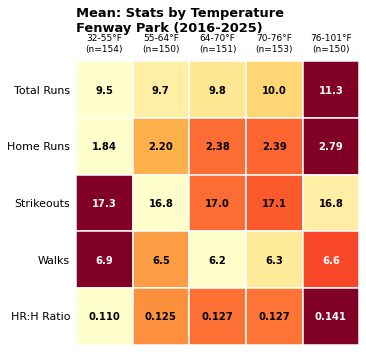

  Saved: heatmap_temp_f_raw.png


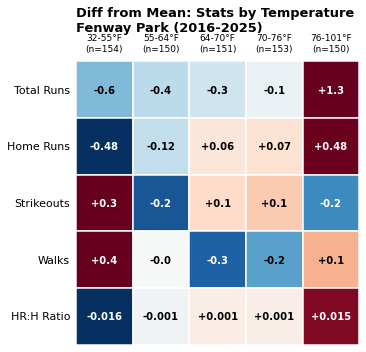

  Saved: heatmap_temp_f_diff.png


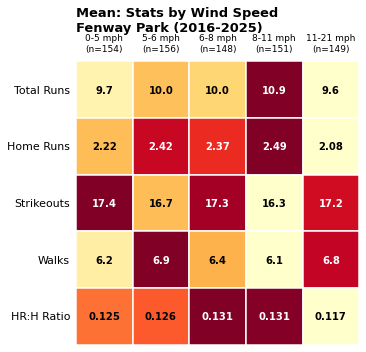

  Saved: heatmap_wspd_mph_raw.png


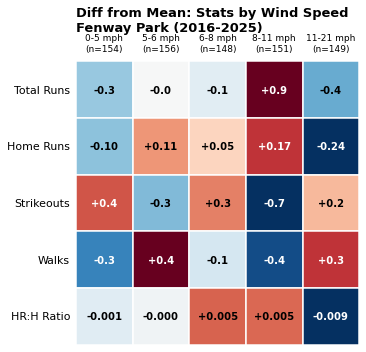

  Saved: heatmap_wspd_mph_diff.png


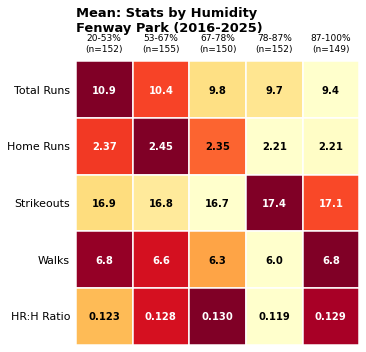

  Saved: heatmap_rhum_raw.png


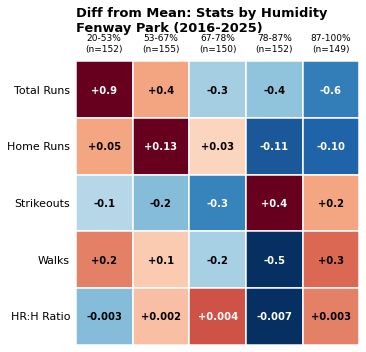

  Saved: heatmap_rhum_diff.png


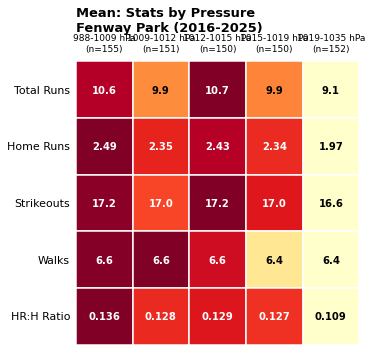

  Saved: heatmap_pres_raw.png


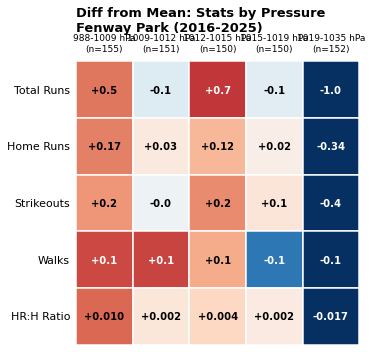

  Saved: heatmap_pres_diff.png

All 8 heatmaps saved to /Users/avabrown/Desktop/DATASCI 192A/Stadium Analysis/Intro Analysis/intro_graphics/BOS


In [13]:
# --- Generate and save all weather heatmaps ---
print(f"Generating weather impact heatmaps for {STADIUM_NAME}...\n")

for weather_col, weather_config in WEATHER_VARS.items():
    for version in ['raw', 'diff']:
        filename = f'heatmap_{weather_col}_{version}.png'
        filepath = os.path.join(GRAPHICS_DIR, filename)

        render_heatmap(team_data, weather_col, weather_config, version, filepath)
        print(f"  Saved: {filename}")

print(f"\nAll 8 heatmaps saved to {os.path.abspath(GRAPHICS_DIR)}")

## Wind Projection Line Graphs

Mean baseball statistics as a function of wind projection toward center field (CF),
left-center field (LCF), and right-center field (RCF). Positive values mean wind
is blowing out (toward the outfield); negative values mean wind is blowing in.

Each wind projection variable is binned into 10 equal-width bins using a shared
range across all three directions. Points with fewer than 5 games are excluded
to avoid noise from small samples.

Generating wind projection line graphs for Fenway Park...



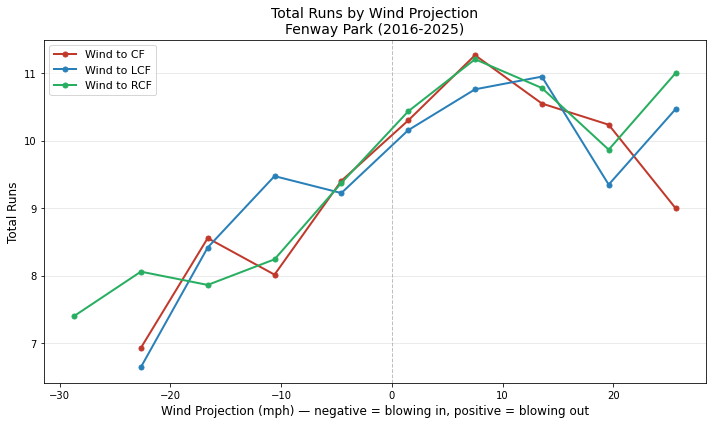

  Saved: wind_projection_total_runs.png


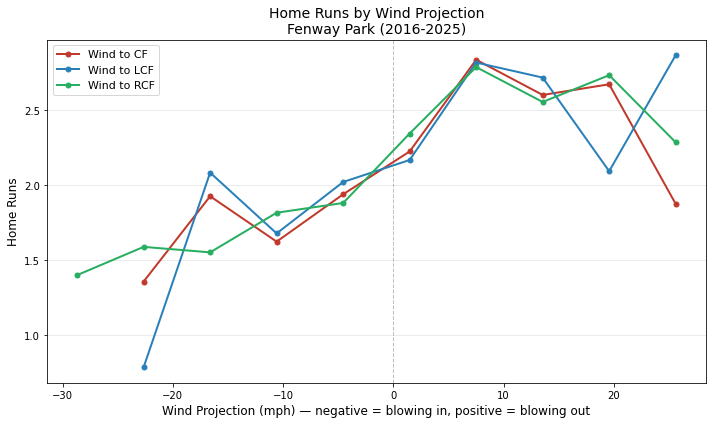

  Saved: wind_projection_home_runs_hit.png


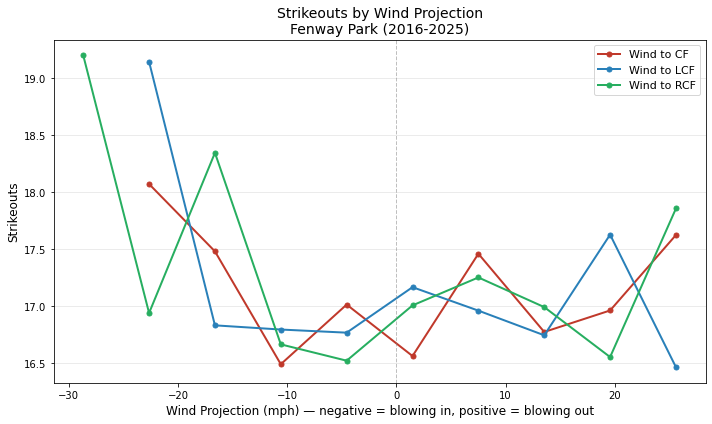

  Saved: wind_projection_strikeouts.png


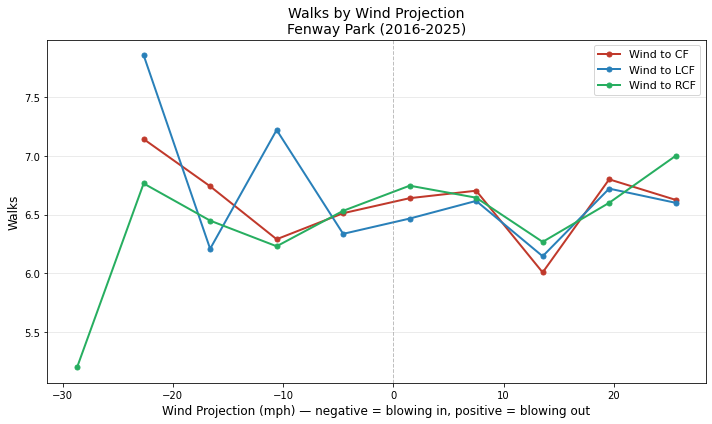

  Saved: wind_projection_walks.png


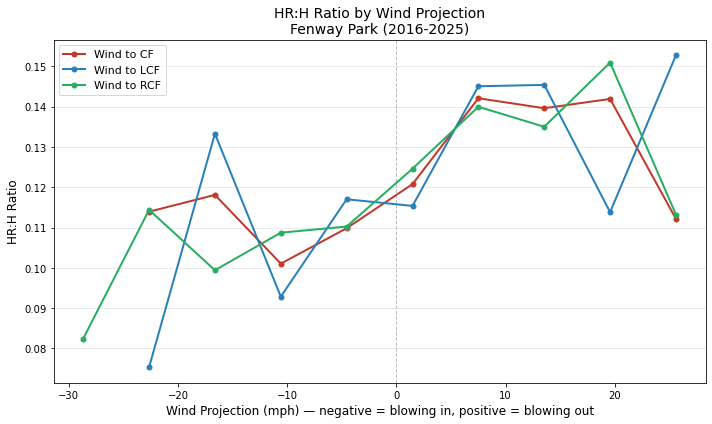

  Saved: wind_projection_hr_h_ratio.png

All 5 line graphs saved to /Users/avabrown/Desktop/DATASCI 192A/Stadium Analysis/Intro Analysis/intro_graphics/BOS


In [14]:
# --- Wind Projection Configuration ---
WIND_PROJ_VARS = {
    'wind_cf':  {'label': 'Wind to CF',  'color': '#c0392b'},
    'wind_lcf': {'label': 'Wind to LCF', 'color': '#2980b9'},
    'wind_rcf': {'label': 'Wind to RCF', 'color': '#27ae60'},
}
MIN_GAMES_PER_BIN = 5
N_WIND_BINS = 10

# Compute shared bin edges across all 3 wind projection variables
all_wind_vals = pd.concat([team_data[c].dropna() for c in WIND_PROJ_VARS])
shared_bins = np.linspace(all_wind_vals.min(), all_wind_vals.max(), N_WIND_BINS + 1)


def render_wind_line_graph(df, stat_col, stat_config, shared_bins, filepath):
    """Render a line graph showing stat vs wind projection for CF/LCF/RCF."""
    fig, ax = plt.subplots(figsize=(10, 6))

    for wind_col, wind_config in WIND_PROJ_VARS.items():
        series = df[[wind_col, stat_col]].dropna()
        series['_bin'] = pd.cut(series[wind_col], bins=shared_bins, include_lowest=True)

        grouped = series.groupby('_bin')[stat_col].agg(['mean', 'count'])
        # Filter out bins with too few games
        grouped = grouped[grouped['count'] >= MIN_GAMES_PER_BIN]

        if len(grouped) == 0:
            continue

        midpoints = [(iv.left + iv.right) / 2 for iv in grouped.index]
        means = grouped['mean'].values

        ax.plot(midpoints, means, marker='o', markersize=5, linewidth=2,
                color=wind_config['color'], label=wind_config['label'])

    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Wind Projection (mph) \u2014 negative = blowing in, positive = blowing out',
                  fontsize=12)
    ax.set_ylabel(stat_config['label'], fontsize=12)
    ax.set_title(f'{stat_config["label"]} by Wind Projection\n'
                 f'{STADIUM_NAME} ({SEASON_START}-{SEASON_END})',
                 fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()


# --- Generate and save all wind projection line graphs ---
print(f"Generating wind projection line graphs for {STADIUM_NAME}...\n")

for stat_col, stat_config in BASEBALL_STATS.items():
    filename = f'wind_projection_{stat_col}.png'
    filepath = os.path.join(GRAPHICS_DIR, filename)

    render_wind_line_graph(team_data, stat_col, stat_config, shared_bins, filepath)
    print(f"  Saved: {filename}")

print(f"\nAll 5 line graphs saved to {os.path.abspath(GRAPHICS_DIR)}")